In [32]:
# !pip install astropy
# !pip install scikit-image

import os

import pandas as pd
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from matplotlib.patches import Ellipse

import re
from astropy.wcs import WCS

from skimage.draw import ellipse

In [33]:
fits_path = "../data/raw/fits/jw02107-o039_t018_miri_f770w_i2d.fits"

hdul = fits.open(fits_path)
hdul.info()

Filename: ../data/raw/fits/jw02107-o039_t018_miri_f770w_i2d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     265   ()      
  1  SCI           1 ImageHDU        75   (2380, 1177)   float32   
  2  ERR           1 ImageHDU        10   (2380, 1177)   float32   
  3  CON           1 ImageHDU        10   (2380, 1177, 1)   int32   
  4  WHT           1 ImageHDU         9   (2380, 1177)   float32   
  5  VAR_POISSON    1 ImageHDU         9   (2380, 1177)   float32   
  6  VAR_RNOISE    1 ImageHDU         9   (2380, 1177)   float32   
  7  VAR_FLAT      1 ImageHDU         9   (2380, 1177)   float32   
  8  HDRTAB        1 BinTableHDU    502   12R x 246C   [23A, 5A, 3A, 48A, 7A, 13A, 6A, 5A, 6A, 7A, 10A, 4A, L, D, D, 32A, 50A, 70A, 11A, 2A, 47A, 10A, 12A, 23A, 23A, 26A, 11A, 5A, 3A, 3A, 2A, 1A, 2A, 1A, L, 12A, 6A, 2A, 26A, 20A, 27A, 10A, K, L, L, L, L, 7A, 7A, 5A, D, D, D, D, D, D, 27A, D, D, 4A, 8A, 5A, 4A, 3A, 4A, K, 5A, 9A, D, D, D, D, D

In [34]:
data = hdul[1].data
header = hdul[1].header

In [35]:
input_path = "../data/raw/catalogue/jwst_bubble_properties_B.txt"
output_path = "../data/raw/catalogue/jwst_bubble_properties_B_fixed.txt"

df = pd.read_csv(input_path)

# Fix only DEC_DMS: e.g. 15h48m6.5s -> 15d48m6.5s
df["DEC_DMS"] = df["DEC_DMS"].astype(str).str.replace("h", "d", regex=False)
df["RA_DMS"] = df["RA_DMS"].astype(str).str.replace("h", "d", regex=False)

df.to_csv(output_path, index=False)

print("Saved fixed catalogue to:", output_path)
print(df[["ID", "RA_DMS", "DEC_DMS"]].head())

Saved fixed catalogue to: ../data/raw/catalogue/jwst_bubble_properties_B_fixed.txt
   ID       RA_DMS      DEC_DMS
0   1  24d08m58.8s  15d47m41.2s
1   2   24d09m2.4s   15d48m2.7s
2   3   24d09m4.3s  15d47m33.3s
3   4   24d09m8.1s  15d47m30.0s
4   5  24d09m14.2s   15d48m6.5s


In [56]:
import pandas as pd

df = pd.read_csv("../data/raw/catalogue/jwst_bubble_properties_B_fixed.txt")

print(df.head())
print(df.columns)

   ID       RA_DMS      DEC_DMS  SEMI_MAJ_PC  SEMI_MIN_PC  AVG_RAD_PC  PA_DEG  \
0   1  24d08m58.8s  15d47m41.2s           28           28          28       0   
1   2   24d09m2.4s   15d48m2.7s           37           37          37       0   
2   3   24d09m4.3s  15d47m33.3s           53           50          52       0   
3   4   24d09m8.1s  15d47m30.0s           56           53          55       0   
4   5  24d09m14.2s   15d48m6.5s           53           53          53       0   

   ARM  DIST_ARM_PC  GAL_RAD_KPC  
0    3           94         4.43  
1    3           78         4.83  
2    3           46         4.05  
3    3           20         3.83  
4    3           -8         4.53  
Index(['ID', 'RA_DMS', 'DEC_DMS', 'SEMI_MAJ_PC', 'SEMI_MIN_PC', 'AVG_RAD_PC',
       'PA_DEG', 'ARM', 'DIST_ARM_PC', 'GAL_RAD_KPC'],
      dtype='str')


In [57]:

ra_dms = df['RA_DMS'].tolist()      # degree to dms
dec_dms = df['DEC_DMS'].tolist()

def ra_dec_to_deg(ra_str, dec_str):
    ra_pattern = re.compile(r'(\d+)d(\d+)m(\d+\.\d+)s')
    dec_pattern = re.compile(r'(\d+)d(\d+)m(\d+\.\d+)s')
    ra_deg, ra_min, ra_sec = map(float, ra_pattern.match(ra_str).groups())
    dec_deg, dec_min, dec_sec = map(float, dec_pattern.match(dec_str).groups())
    ra_decimal = ra_deg + ra_min / 60 + ra_sec / 3600
    dec_decimal = dec_deg + dec_min / 60 + dec_sec / 3600

    return ra_decimal, dec_decimal

def deg_to_dec(data_in_str):
    data_pattern = re.compile(r'(\d+)d(\d+)m(\d+\.\d+)s')
    data_deg, data_min, data_sec = map(float, data_pattern.match(data_in_str).groups())
    data_in_decimal = data_deg + data_min / 60 + data_sec / 3600

    return data_in_decimal


ra_degrees = np.zeros(len(df), dtype=float)
dec_degrees = np.zeros(len(df), dtype=float)
for i, row in df.iterrows():
    ra_deg, dec_deg = ra_dec_to_deg(row['RA_DMS'], row['DEC_DMS'])
    ra_degrees[i] = ra_deg
    dec_degrees[i] = dec_deg

In [58]:
wcs = WCS(header)

x_pix, y_pix = wcs.all_world2pix(ra_degrees, dec_degrees, 0)


Set DATE-AVG to '2022-07-17T12:01:53.586' from MJD-AVG.
Set DATE-END to '2022-07-17T12:54:46.016' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -37.754891 from OBSGEO-[XYZ].
Set OBSGEO-H to 1738895745.202 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [59]:
# mask generation :  parsec to pixel

# Distance to NGC 628 in parsecs
distance_pc = 9.77e6

# Pixel scale from FITS header
pixel_scale_deg = abs(header['CDELT1'])
pixel_scale_arcsec = pixel_scale_deg * 3600

# Physical scale
pc_per_arcsec = distance_pc / 206265
pc_per_pixel = pixel_scale_arcsec * pc_per_arcsec

print("pc per pixel:", pc_per_pixel)

pc per pixel: 5.254140159227344


In [60]:
mask = np.zeros(data.shape, dtype=np.uint8)     

In [61]:
# semi major and semi minor conversion

semi_major_pix = df['SEMI_MAJ_PC'] / pc_per_pixel
semi_minor_pix = df['SEMI_MIN_PC'] / pc_per_pixel
pa_deg = df['PA_DEG']

In [62]:
height, width = mask.shape

for i in range(len(df)):
    x0 = x_pix[i]
    y0 = y_pix[i]

    a = semi_major_pix.iloc[i]
    b = semi_minor_pix.iloc[i]
    pa = np.deg2rad(pa_deg.iloc[i])

    if np.isnan(x0) or np.isnan(y0) or np.isnan(a) or np.isnan(b):
        continue

    rr, cc = ellipse(
        r=y0,
        c=x0,
        r_radius=b,
        c_radius=a,
        rotation=pa,
        shape=mask.shape
    )

    mask[rr, cc] = 1

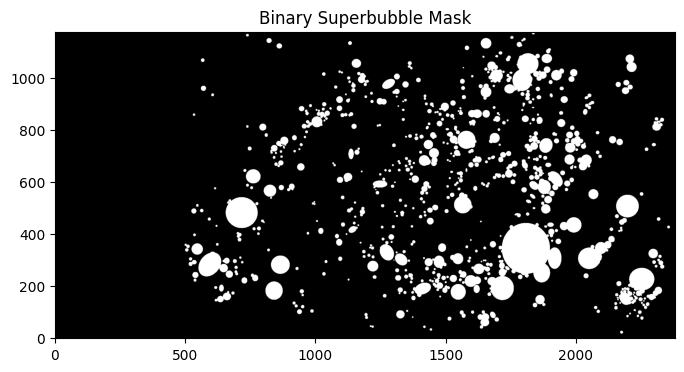

In [63]:
plt.figure(figsize=(8, 8))
plt.imshow(mask, origin="lower", cmap="gray")
plt.title("Binary Superbubble Mask")
plt.show()